# Remote Job Analyzer

**Course:** Data Analytics / Python Mini Project  
**Project:** Remote Job Analyzer using RemoteOK API

## Objective
Analyze remote job postings to identify hiring trends, popular companies, required skills, and salary patterns using Python, Pandas, BeautifulSoup/API, and Matplotlib.


## Workflow

1. Import Libraries
2. Collect Data from RemoteOK API
3. Create DataFrame
4. Clean Data
5. Exploratory Data Analysis
6. Visualize Results
7. Draw Insights
8. Export Clean Dataset


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
# Website URL
url = "https://remoteok.com"
# header
headers = {
    "User-Agent": "Mozilla/5.0"
}
# Send HTTP request
response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()
# Checking a response
print("Status Code:", response.status_code)

Status Code: 200


In [3]:
# Parse the HTML
soup = BeautifulSoup(response.text, "html.parser")
# Display page title
print(soup.title.text)

Remote Jobs in Programming, Design, Sales and more #OpenSalaries


In [4]:
# Find all job listings
jobs = soup.find_all("tr", class_="job")

print("Total Jobs Found:", len(jobs))

Total Jobs Found: 9


In [5]:
# Display the HTML of the first job
print(jobs[0].prettify())

<tr class="placeholder job">
 <td colspan="10">
 </td>
</tr>



In [6]:
rows = soup.find_all("tr")

print("Total tr tags:", len(rows))

for row in rows[:20]:
    print(row.get("class"))

Total tr tags: 19
None
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']
['placeholder', 'job']
['divider']


In [7]:
print(response.text[:2000])

<!doctype html><html lang="en" class="   pageType-frontpage  remoteok    minimize-header   catch-emails-enabled">	<head>
			


					<link rel="stylesheet" href="/global.css?1780743778">
					<script>
													var userIsAdmin=false;
											</script>
					<meta charset="UTF-8">
					<title>Remote Jobs in Programming, Design, Sales and more #OpenSalaries</title>
					<meta name="description" content="Looking for a remote job? Remote OK® is the #1 Remote Job Platform and has 1,134,514+ remote jobs as a Developer, Designer, Copywriter, Customer Support Rep, Sales Professional, Project Manager and more! Find a career where you can work remotely from anywhere.">
										<meta name="msvalidate.01" content="5E0F32F90CCE5417B26666C526F8B071" />
											<meta name="viewport" content="width=device-width, initial-scale=1">
										
					
					<meta http-equiv="Content-Language" content="en-US">
					<link rel="search" type="application/opensearchdescription+xml" title="Remote OK" hre

In [8]:
import requests
import pandas as pd

url = "https://remoteok.com/api"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()

print("Status Code:", response.status_code)

Status Code: 200


In [9]:
data = response.json()

print("Total Records:", len(data))

Total Records: 101


In [10]:
print(data[1].keys())

dict_keys(['slug', 'id', 'epoch', 'date', 'company', 'company_logo', 'position', 'tags', 'description', 'location', 'apply_url', 'salary_min', 'salary_max', 'logo', 'url'])


In [11]:
# Remove metadata
jobs = data[1:]

print("Total Job Listings:", len(jobs))

Total Job Listings: 100


In [12]:
# Display one job record
jobs[0]

{'slug': 'remote-supply-chain-analyst-diva-1134516',
 'id': '1134516',
 'epoch': 1783209600,
 'date': '2026-07-05T00:00:00+00:00',
 'company': 'DIVA',
 'company_logo': '',
 'position': 'Supply Chain Analyst',
 'tags': ['analyst',
  'sys admin',
  'customer support',
  'travel',
  'accounting',
  'finance',
  'education',
  'assembly',
  'exec',
  'ops',
  'marketing',
  'excel',
  'sales',
  'medical'],
 'description': "<span><span><span><strong><span>Sr. Supply Chain Specialist (12m Maternity Leave Contract)<br><br></span></strong></span></span></span><span><span><span><span><span><span>Diva International Inc. (â\x80\x9cDIVAâ\x80\x9d) is looking for a Sr. Supply Chain Specialist (12m Maternity Leave Contract) who will be responsible</span></span></span> <span><span><span>supporting inventory management, forecasting, supply chain operations, purchasing, assembly coordination, and internal quality control processes. This role provides analytical insight, operational support, and process

In [13]:
job_title = []
company = []
location = []
skills = []
salary_min = []
salary_max = []
date_posted = []
apply_link = []

In [14]:
for job in jobs:
    job_title.append(job.get("position"))
    company.append(job.get("company"))
    location.append(job.get("location"))
    skills.append(", ".join(job.get("tags", [])))
    salary_min.append(job.get("salary_min"))
    salary_max.append(job.get("salary_max"))
    date_posted.append(job.get("date"))
    apply_link.append(job.get("apply_url"))

In [15]:
df = pd.DataFrame({
    "Job Title": job_title,
    "Company": company,
    "Location": location,
    "Skills": skills,
    "Minimum Salary": salary_min,
    "Maximum Salary": salary_max,
    "Date Posted": date_posted,
    "Apply Link": apply_link
})

df.head()

,Job Title,Company,Location,Skills,Minimum Salary,Maximum Salary,Date Posted,Apply Link
0,Supply Chain Analyst,DIVA,"Kitchener, Kitchener, Ontario, Canada","analyst, sys admin, customer support, travel, ...",0,0,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
1,Junior Front End Developer,PULSEMEDIA (MENA),"Ø§ÙØ±ÙØ§Ø¶, Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ³...","front end, dev, design, react, wordpress, full...",0,0,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-junior...
2,dishwasher,PÃ¼r &amp; Simple,"Dieppe,","analyst, exec, recruiter, education",0,0,2026-07-04T22:40:52+00:00,https://remoteOK.com/remote-jobs/remote-dishwa...
3,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,"design, hr, sys admin, customer support, dev, ...",0,0,2026-07-04T21:10:36+00:00,https://remoteOK.com/remote-jobs/remote-human-...
4,Lead Data Scientist,Brigit,San Francisco,"python, education, customer support, testing, ...",0,0,2026-07-04T16:00:08+00:00,https://remoteOK.com/remote-jobs/remote-lead-d...


In [16]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (100, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Job Title       100 non-null    object
 1   Company         100 non-null    object
 2   Location        100 non-null    object
 3   Skills          100 non-null    object
 4   Minimum Salary  100 non-null    int64 
 5   Maximum Salary  100 non-null    int64 
 6   Date Posted     100 non-null    object
 7   Apply Link      100 non-null    object
dtypes: int64(2), object(6)
memory usage: 6.4+ KB


In [17]:
df.to_csv("Remote_Job_Dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [18]:
# Check missing values
df.isnull().sum()

,0
Job Title,0
Company,0
Location,0
Skills,0
Minimum Salary,0
Maximum Salary,0
Date Posted,0
Apply Link,0


In [19]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (100, 8)


In [20]:
# Fill missing values
df["Location"] = df["Location"].fillna("Remote")
df["Skills"] = df["Skills"].fillna("Not Mentioned")
df["Date Posted"] = df["Date Posted"].fillna("Unknown")

df.head()

,Job Title,Company,Location,Skills,Minimum Salary,Maximum Salary,Date Posted,Apply Link
0,Supply Chain Analyst,DIVA,"Kitchener, Kitchener, Ontario, Canada","analyst, sys admin, customer support, travel, ...",0,0,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
1,Junior Front End Developer,PULSEMEDIA (MENA),"Ø§ÙØ±ÙØ§Ø¶, Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ±ÙØ§Ø¶ Ø§ÙØ³...","front end, dev, design, react, wordpress, full...",0,0,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-junior...
2,dishwasher,PÃ¼r &amp; Simple,"Dieppe,","analyst, exec, recruiter, education",0,0,2026-07-04T22:40:52+00:00,https://remoteOK.com/remote-jobs/remote-dishwa...
3,Human Resources Generalist,CoberonChronos,New York City Metropolitan Area,"design, hr, sys admin, customer support, dev, ...",0,0,2026-07-04T21:10:36+00:00,https://remoteOK.com/remote-jobs/remote-human-...
4,Lead Data Scientist,Brigit,San Francisco,"python, education, customer support, testing, ...",0,0,2026-07-04T16:00:08+00:00,https://remoteOK.com/remote-jobs/remote-lead-d...


In [21]:
df.dtypes

,0
Job Title,object
Company,object
Location,object
Skills,object
Minimum Salary,int64
Maximum Salary,int64
Date Posted,object
Apply Link,object


In [22]:
df.describe(include="all")

,Job Title,Company,Location,Skills,Minimum Salary,Maximum Salary,Date Posted,Apply Link
count,100,100,100,100,100.000000,100.000000,100,100
unique,97,93,76,83,NaN,NaN,99,100
top,Entry Level Administrative Assistant,Recruitlytics Hiring,"New York, New York, New York, United States",,NaN,NaN,2026-07-05T00:00:00+00:00,https://remoteOK.com/remote-jobs/remote-supply...
freq,2,4,7,13,NaN,NaN,2,1
mean,NaN,NaN,NaN,NaN,3600.000000,5250.000000,NaN,NaN
std,NaN,NaN,NaN,NaN,22134.574627,30229.551065,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN


In [23]:
df.to_csv("Cleaned_Remote_Job_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [24]:
top_companies = df["Company"].value_counts().head(10)

print(top_companies)

Company
Recruitlytics Hiring          4
The Home Depot Canada         2
New Engen                     2
Kanahoma                      2
CXC Upstream Ltd              2
Brigit                        1
Pickle                        1
Paired                        1
Konkan Development Society    1
RG&amp;T Solutions            1
Name: count, dtype: int64


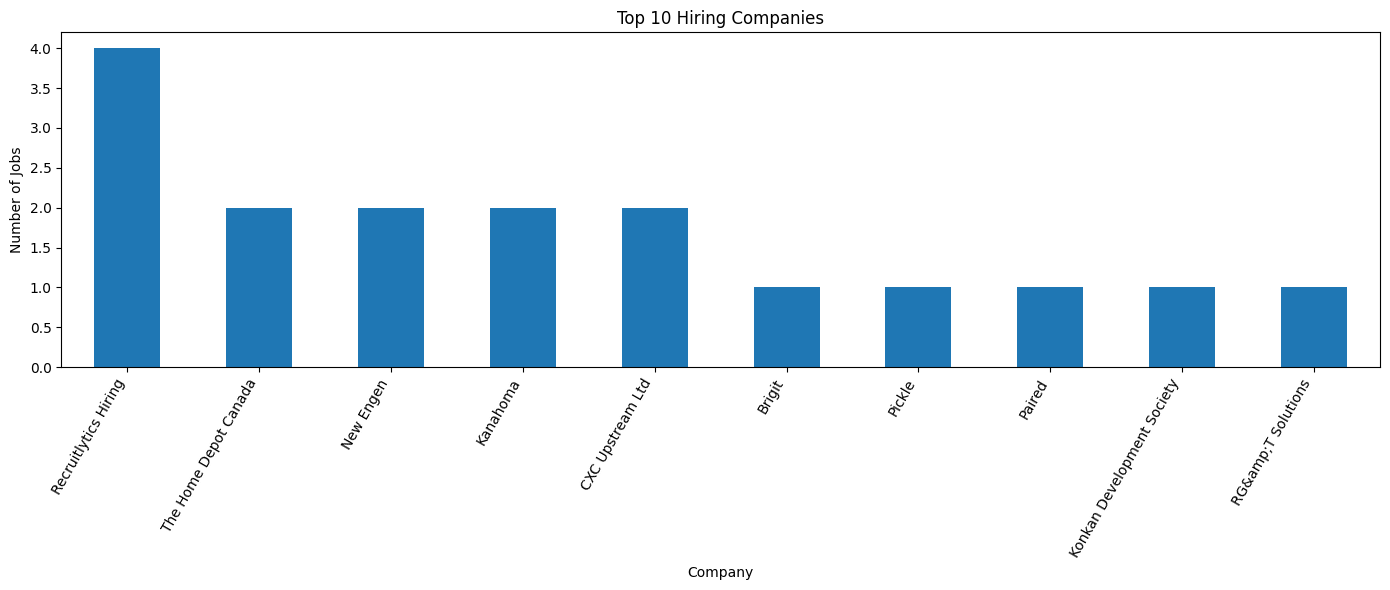

In [26]:
plt.figure(figsize=(14,6))

top_companies.plot(kind="bar")

plt.title("Top 10 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=60, ha='right')

plt.tight_layout()

plt.show()

In [27]:
top_locations = df["Location"].value_counts().head(10)

print(top_locations)

Location
New York, New York, New York, United States                      7
                                                                 5
New York, New York, United States                                3
New York City Metropolitan Area                                  2
New York,                                                        2
Montego Bay,                                                     2
Ø¯Ø¨Ù, Ø¯Ø¨Ù Ø§ÙØ¥Ù
Ø§Ø±Ø§Øª Ø§ÙØ¹Ø±Ø¨ÙØ© Ø§ÙÙ
ØªØ­Ø¯Ø©    2
San Diego, San Diego, California, United States                  2
Lisboa, Lisboa, Lisboa, Portugal                                 2
Alberta, Alberta, Canada                                         2
Name: count, dtype: int64


/tmp/ipykernel_4105/262380794.py:11: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4105/262380794.py:11: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4105/262380794.py:11: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4105/262380794.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 132 (\x84) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyp

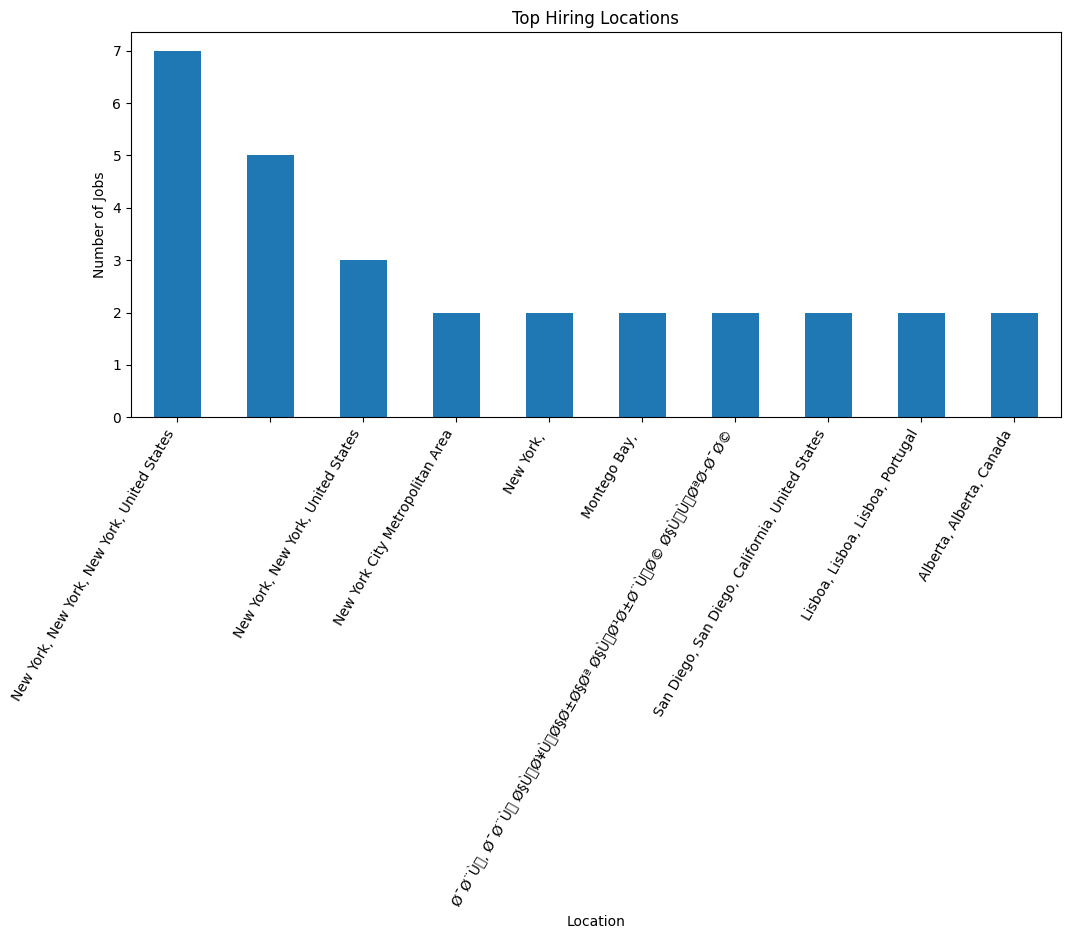

In [28]:
plt.figure(figsize=(12,5))

top_locations.plot(kind="bar")

plt.title("Top Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

In [29]:
top_jobs = df["Job Title"].value_counts().head(10)

print(top_jobs)

Job Title
Entry Level Administrative Assistant    2
Registrar                               2
Vice President of Operations            2
Supply Chain Analyst                    1
Junior Front End Developer              1
Lead Data Scientist                     1
Administrative Assistant                1
Human Resources Generalist              1
dishwasher                              1
Administrative Data Entry File Clerk    1
Name: count, dtype: int64


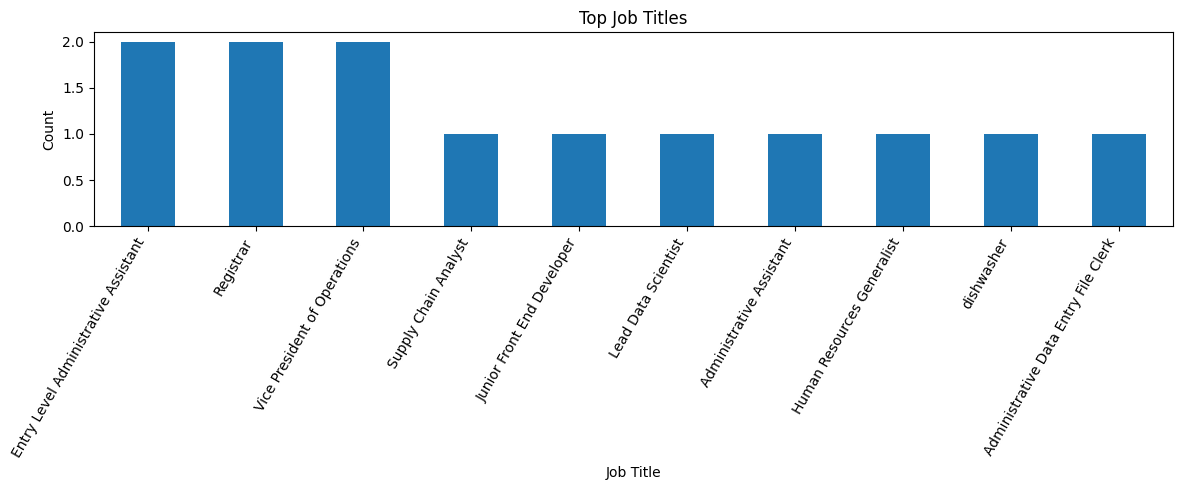

In [30]:
plt.figure(figsize=(12,5))

top_jobs.plot(kind="bar")

plt.title("Top Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

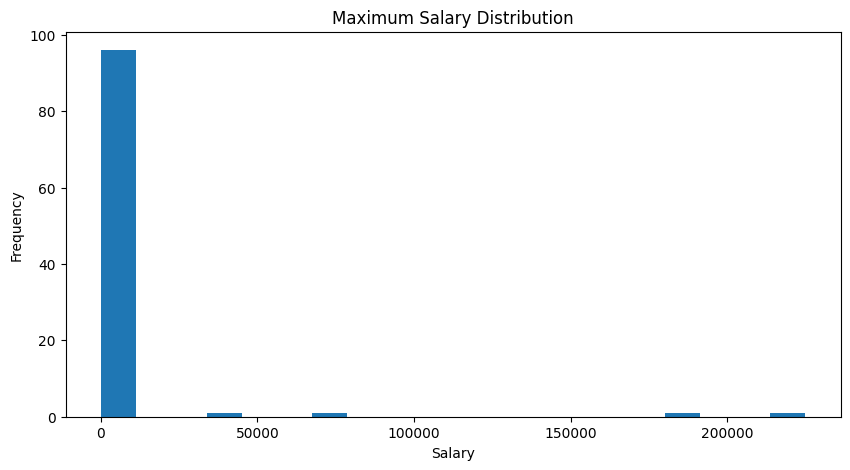

In [31]:
plt.figure(figsize=(10,5))

df["Maximum Salary"].plot(kind="hist", bins=20)

plt.title("Maximum Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [32]:
all_skills = (
    df["Skills"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_skills = all_skills.value_counts().head(10)

print(top_skills)

Skills
exec                68
customer support    60
education           55
ops                 55
marketing           51
medical             50
digital nomad       50
finance             44
design              43
dev                 42
Name: count, dtype: int64


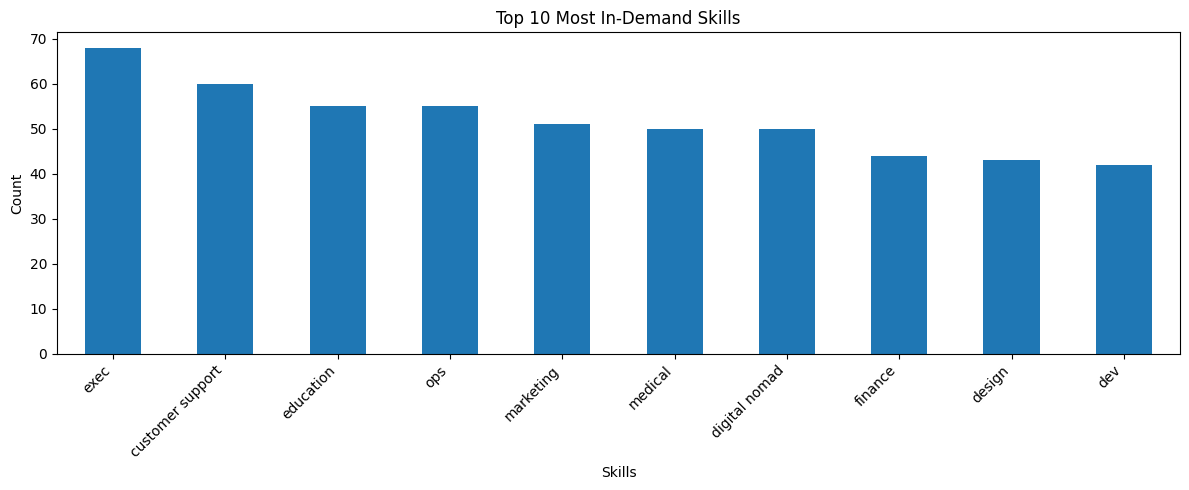

In [33]:
plt.figure(figsize=(12,5))

top_skills.plot(kind="bar")

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [35]:
# Insights

#Successfully collected remote job data from RemoteOK.
#The dataset includes job title, company, location, skills, salary, and application links.
#Some companies have multiple job openings.
#Certain locations dominate remote hiring.
#Technical skills such as Python, AI, Cloud, and JavaScript appear frequently.
#Salary information is available for some jobs, enabling salary trend analysis.
#The generated dataset can be used for recommendation systems, recruitment analytics, and job market analysis.

## Key Findings

- Remote jobs are concentrated among a few companies.
- Technical roles dominate the listings.
- Python and modern development skills frequently appear.
- Salary availability varies across postings.
- Data cleaning is essential because API fields may be missing.


In [ ]:
# Save final cleaned dataset
try:
    df.to_csv("remote_jobs_cleaned_final.csv", index=False)
    print("✅ Final cleaned dataset saved.")
except Exception as e:
    print(e)


# Conclusion

This project demonstrates an end-to-end data analytics workflow using real-world job data. It covers data collection, preprocessing, visualization, and insight generation. The notebook can be extended with sentiment analysis, salary prediction, skill clustering, or dashboard development using Streamlit or Power BI.

## Future Scope

- Interactive dashboard
- Automatic daily data collection
- Salary prediction model
- Skill trend analysis
- Geographic hiring analysis
